##### Import the libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

##### Load the datasets

In [ ]:
oncology = pd.read_csv(r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Data\TimeSeries\Oncology_Ward_TimeSeries.csv")

In [10]:
oncology.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3655 entries, 0 to 3654
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   hospital_id     3655 non-null   object 
 1   datetime        3655 non-null   object 
 2   ward            3655 non-null   object 
 3   occupied_beds   3655 non-null   float64
 4   staffed_beds    3655 non-null   float64
 5   occupancy_rate  3655 non-null   float64
dtypes: float64(3), object(3)
memory usage: 171.5+ KB


- Run the ADF test for every hospital

In [11]:
oncology["hospital_id"].unique()

array(['HHN-BIR-01', 'HHN-EDI-01', 'HHN-LON-01', 'HHN-LON-02',
       'HHN-MAN-01'], dtype=object)

In [12]:
results = []

for hospital in oncology["hospital_id"].unique():
    hospital_data = (oncology[oncology["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    adf = adfuller(hospital_data["occupied_beds"])
    results.append({"Hospital": hospital, "ADF Statistic": round(adf[0],4), "p-value": round(adf[1],4), 
                    "Stationary": "Yes" if adf[1] < 0.05 else "No"})

adf_results = pd.DataFrame(results)

print(f"ADF Test Results for Oncology Unit Occupied Beds")
adf_results

ADF Test Results for Oncology Unit Occupied Beds


,Hospital,ADF Statistic,p-value,Stationary
0,HHN-BIR-01,-7.4171,0.0000,Yes
1,HHN-EDI-01,-7.1827,0.0000,Yes
2,HHN-LON-01,-3.7038,0.0041,Yes
3,HHN-LON-02,-4.3049,0.0004,Yes
4,HHN-MAN-01,-6.2568,0.0000,Yes


      All five Oncology Units have stationary bed occupancy data.
      P-values are below 0.05, confirming statistical significance.
      Bed occupancy fluctuates around a stable long-term average.
      No differencing is required before forecasting (d = 0).
      The data is suitable for ARIMA-based forecasting models.

- Autocorrelation (ACF) for all hospitals

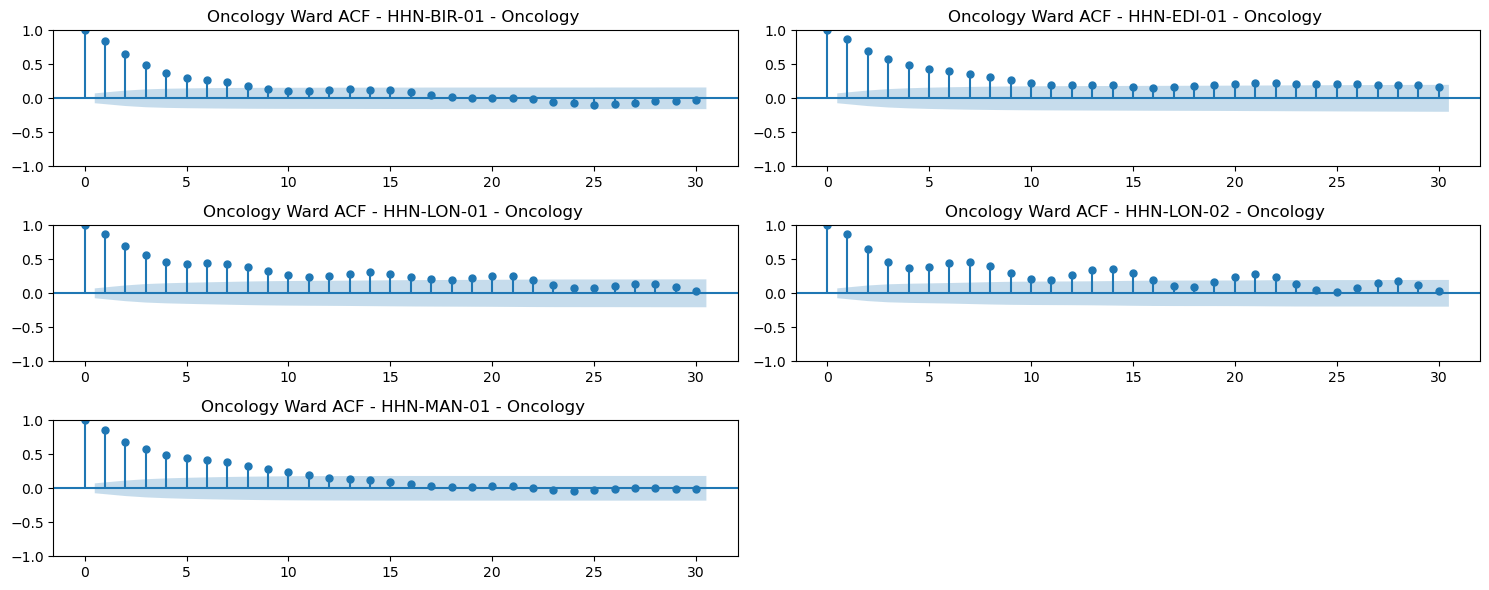

In [13]:
# Create subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 6))
axes = axes.flatten()

# Loop through hospitals
for i, hospital in enumerate(sorted(oncology["hospital_id"].unique())):

    hospital_data = (oncology[oncology["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    plot_acf(hospital_data["occupied_beds"], lags=30,ax=axes[i])
    axes[i].set_title(f"Oncology Ward ACF - {hospital} - Oncology ")

# Remove unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

      Oncology Units have strong day-to-day memory, with occupancy influenced by previous days.
      Weekly (7-day) and two-week (14-day) patterns are evident, reflecting regular treatment schedules.
      London and Edinburgh have longer-lasting occupancy patterns, while Birmingham and Manchester show shorter memory.
      Bed occupancy is influenced by both patient length of stay and scheduled treatment cycles.
      A Seasonal ARIMA (SARIMA) model is appropriate, combining autoregressive terms (p = 1 or 2) with a 7-day seasonal component, while longer treatment cycles (14 or 21 days) may also improve forecasting performance.

- PACF for all hospitals

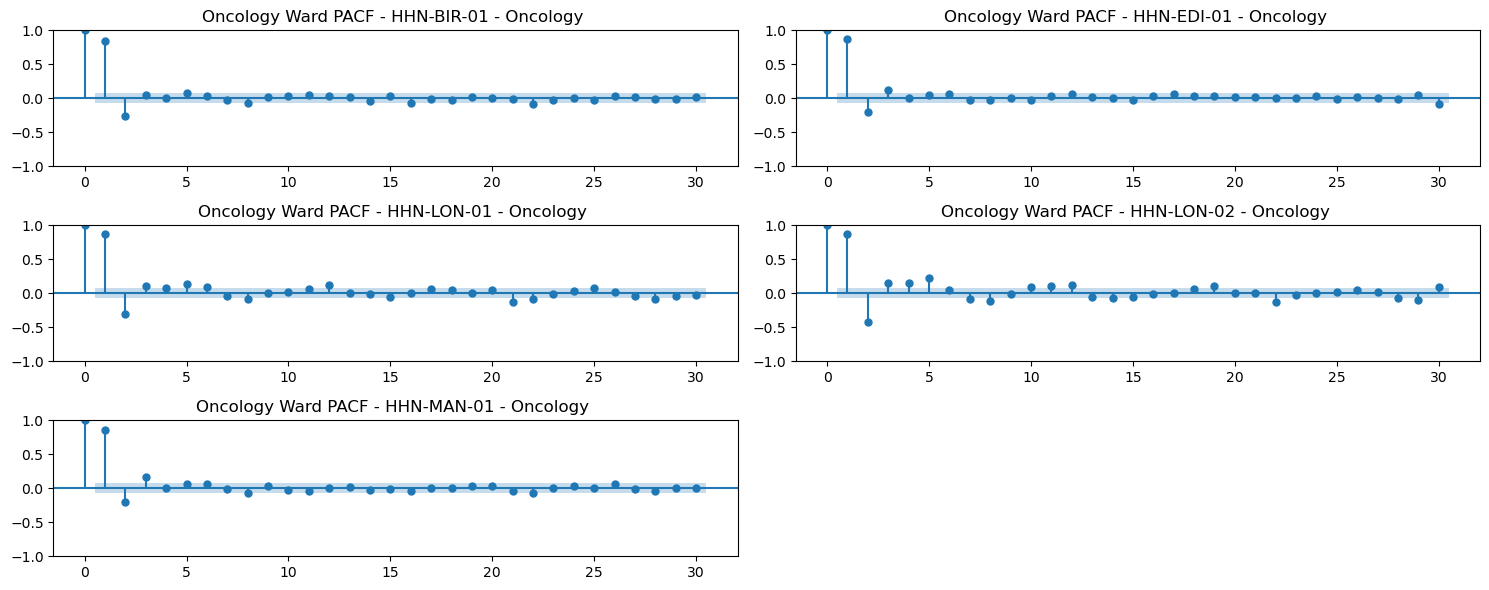

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(15, 6))
axes = axes.flatten()

for i, hospital in enumerate(sorted(oncology["hospital_id"].unique())):

    hospital_data = (oncology[oncology["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    plot_pacf(hospital_data["occupied_beds"], lags=30, ax=axes[i], method="ywm")
    axes[i].set_title(f"Oncology Ward PACF - {hospital} - Oncology ")
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

      Yesterday's occupancy (Lag 1) has the strongest influence on today's occupancy.
      Lag 2 shows a negative relationship, reflecting the effect of planned patient discharges.
      Oncology occupancy has a 2-day autoregressive memory (massive spike at Lag 1 and a sharp negative bounce at Lag 2 before completely cutting off.)
      The data is stationary, so no differencing is required.
      Weekly treatment schedules create a 7-day seasonal pattern, making a SARIMA model suitable for forecasting.
      A good starting forecasting model is SARIMA(2, 0, 0) × (1, 0, 0)₇, which captures both the short-term patient carry-over and the weekly treatment cycle.

- Seasonal Decomposition for all hospitals

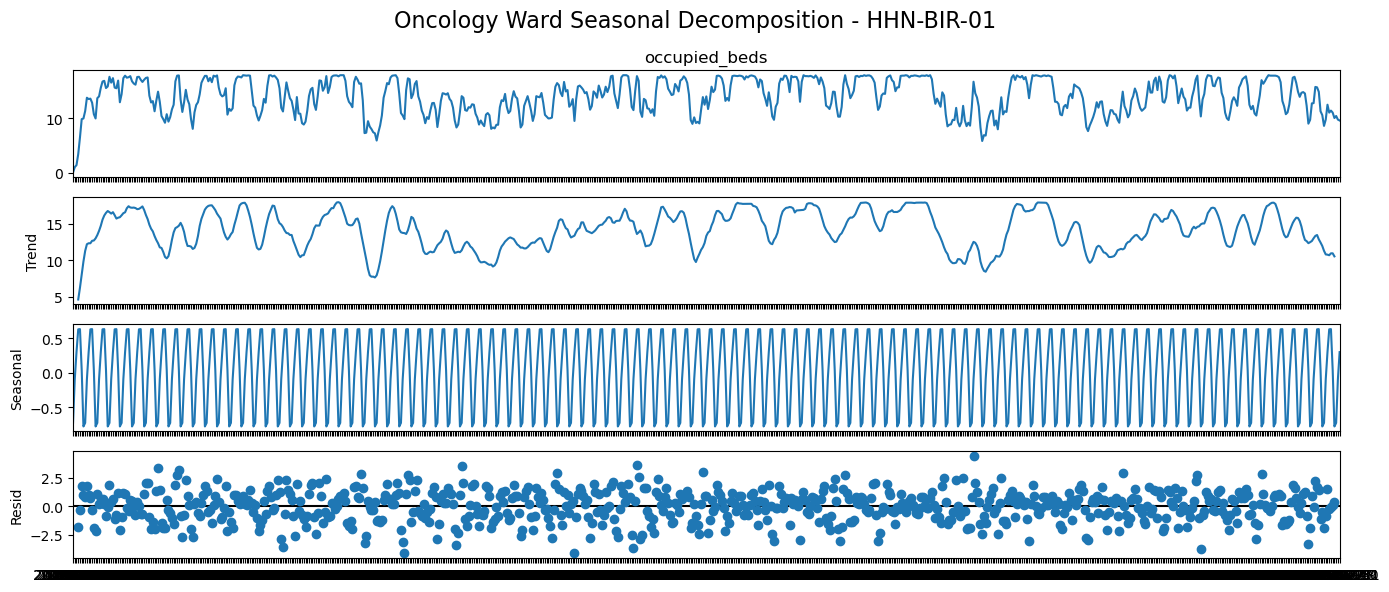

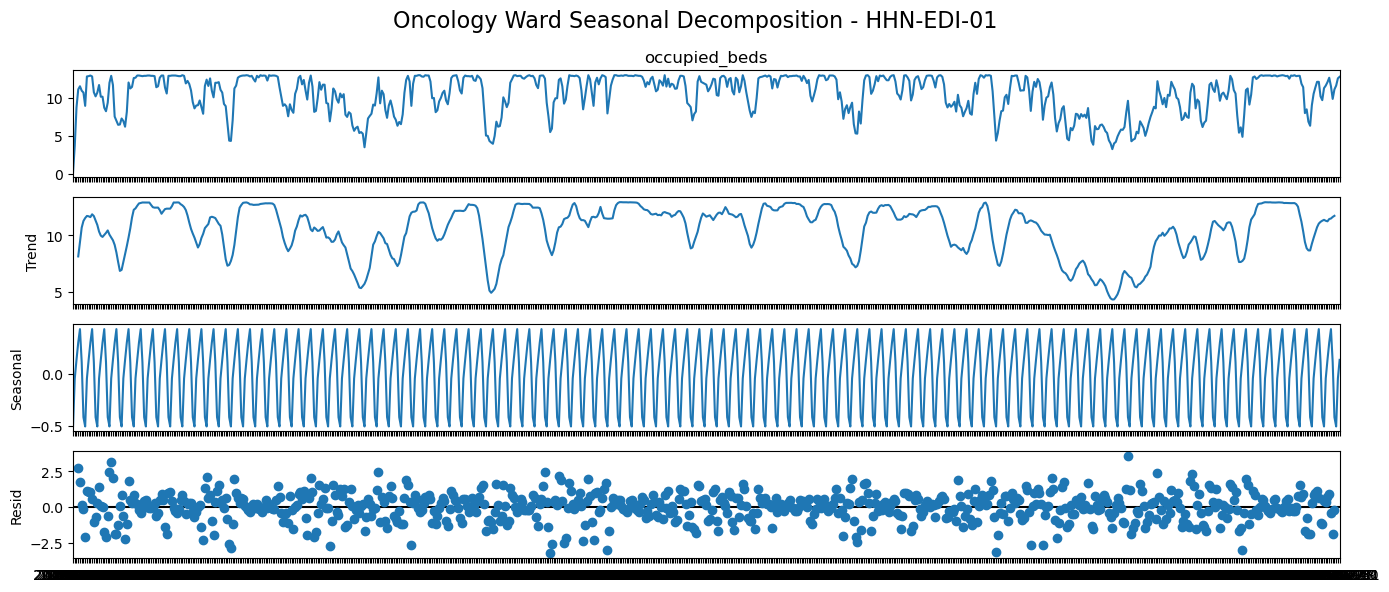

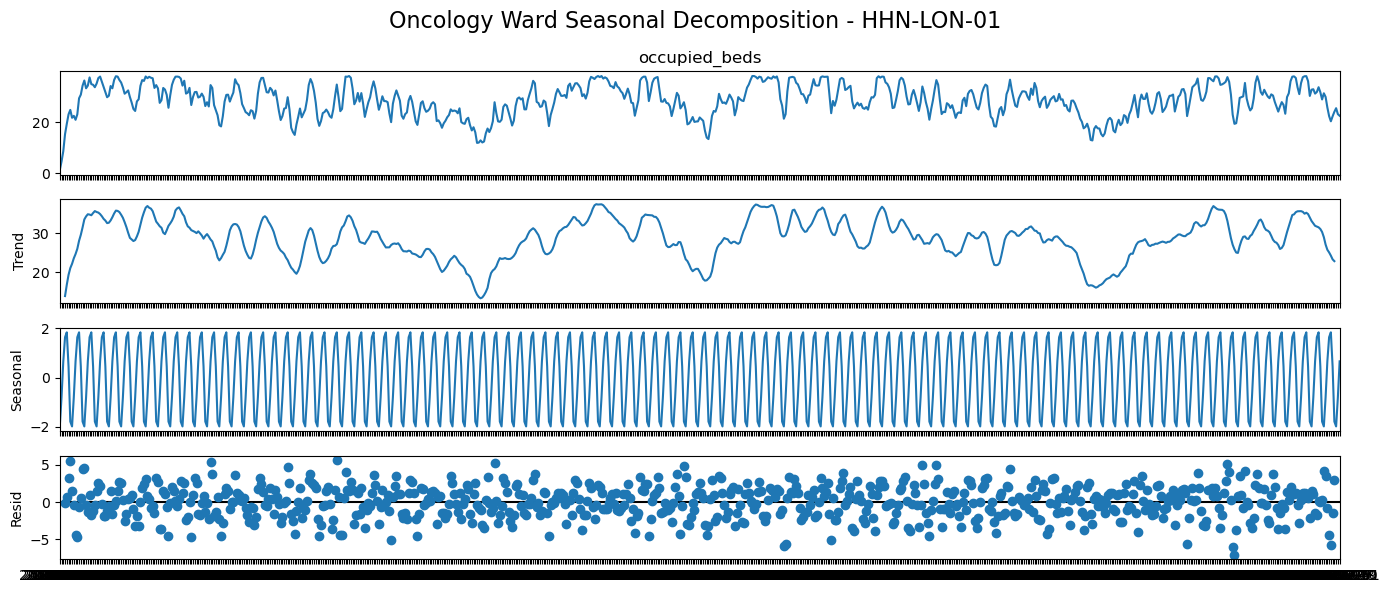

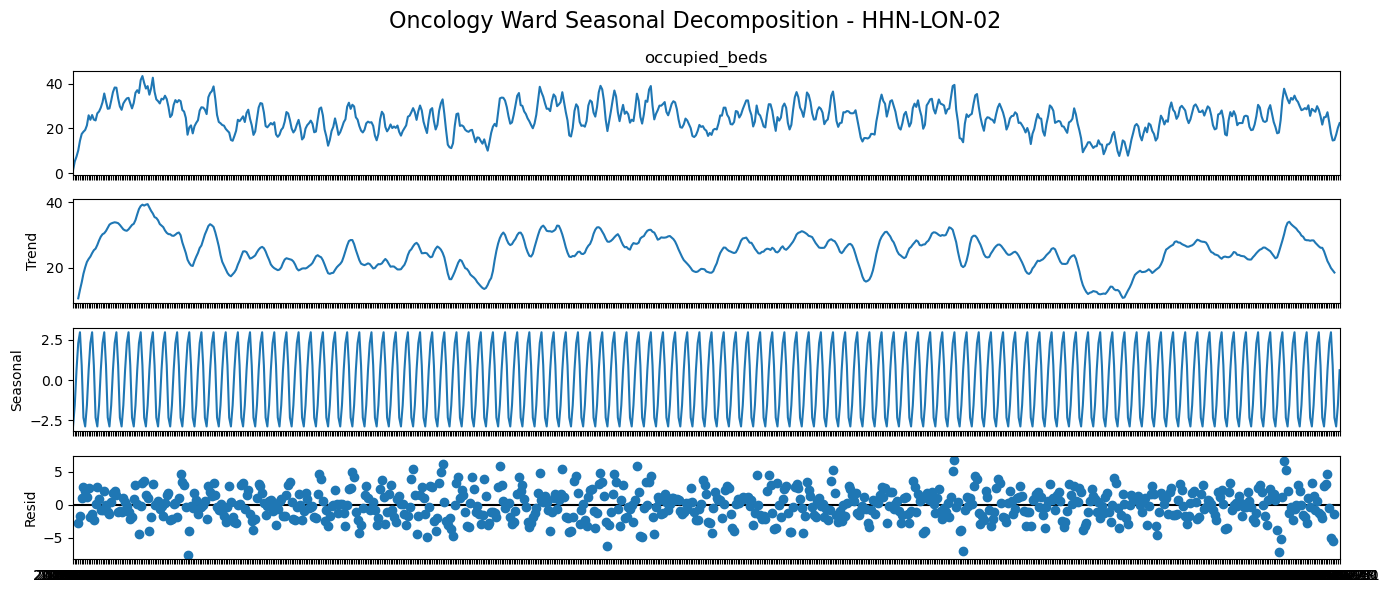

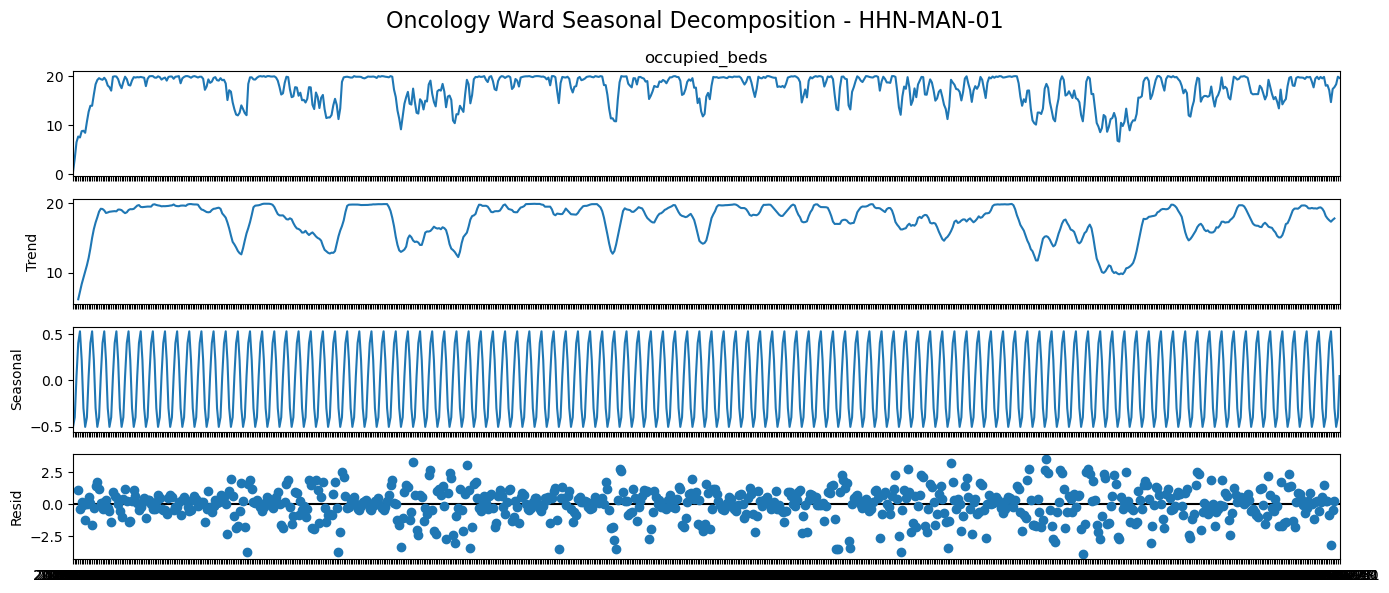

In [15]:
for hospital in sorted(oncology["hospital_id"].unique()):

    hospital_data = (oncology[oncology["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    result = seasonal_decompose(hospital_data["occupied_beds"], model="additive", period=7)
    fig = result.plot()
    fig.set_size_inches(14,6)
    fig.suptitle(f"Oncology Ward Seasonal Decomposition - {hospital}", fontsize=16)
    plt.tight_layout()
    plt.show()

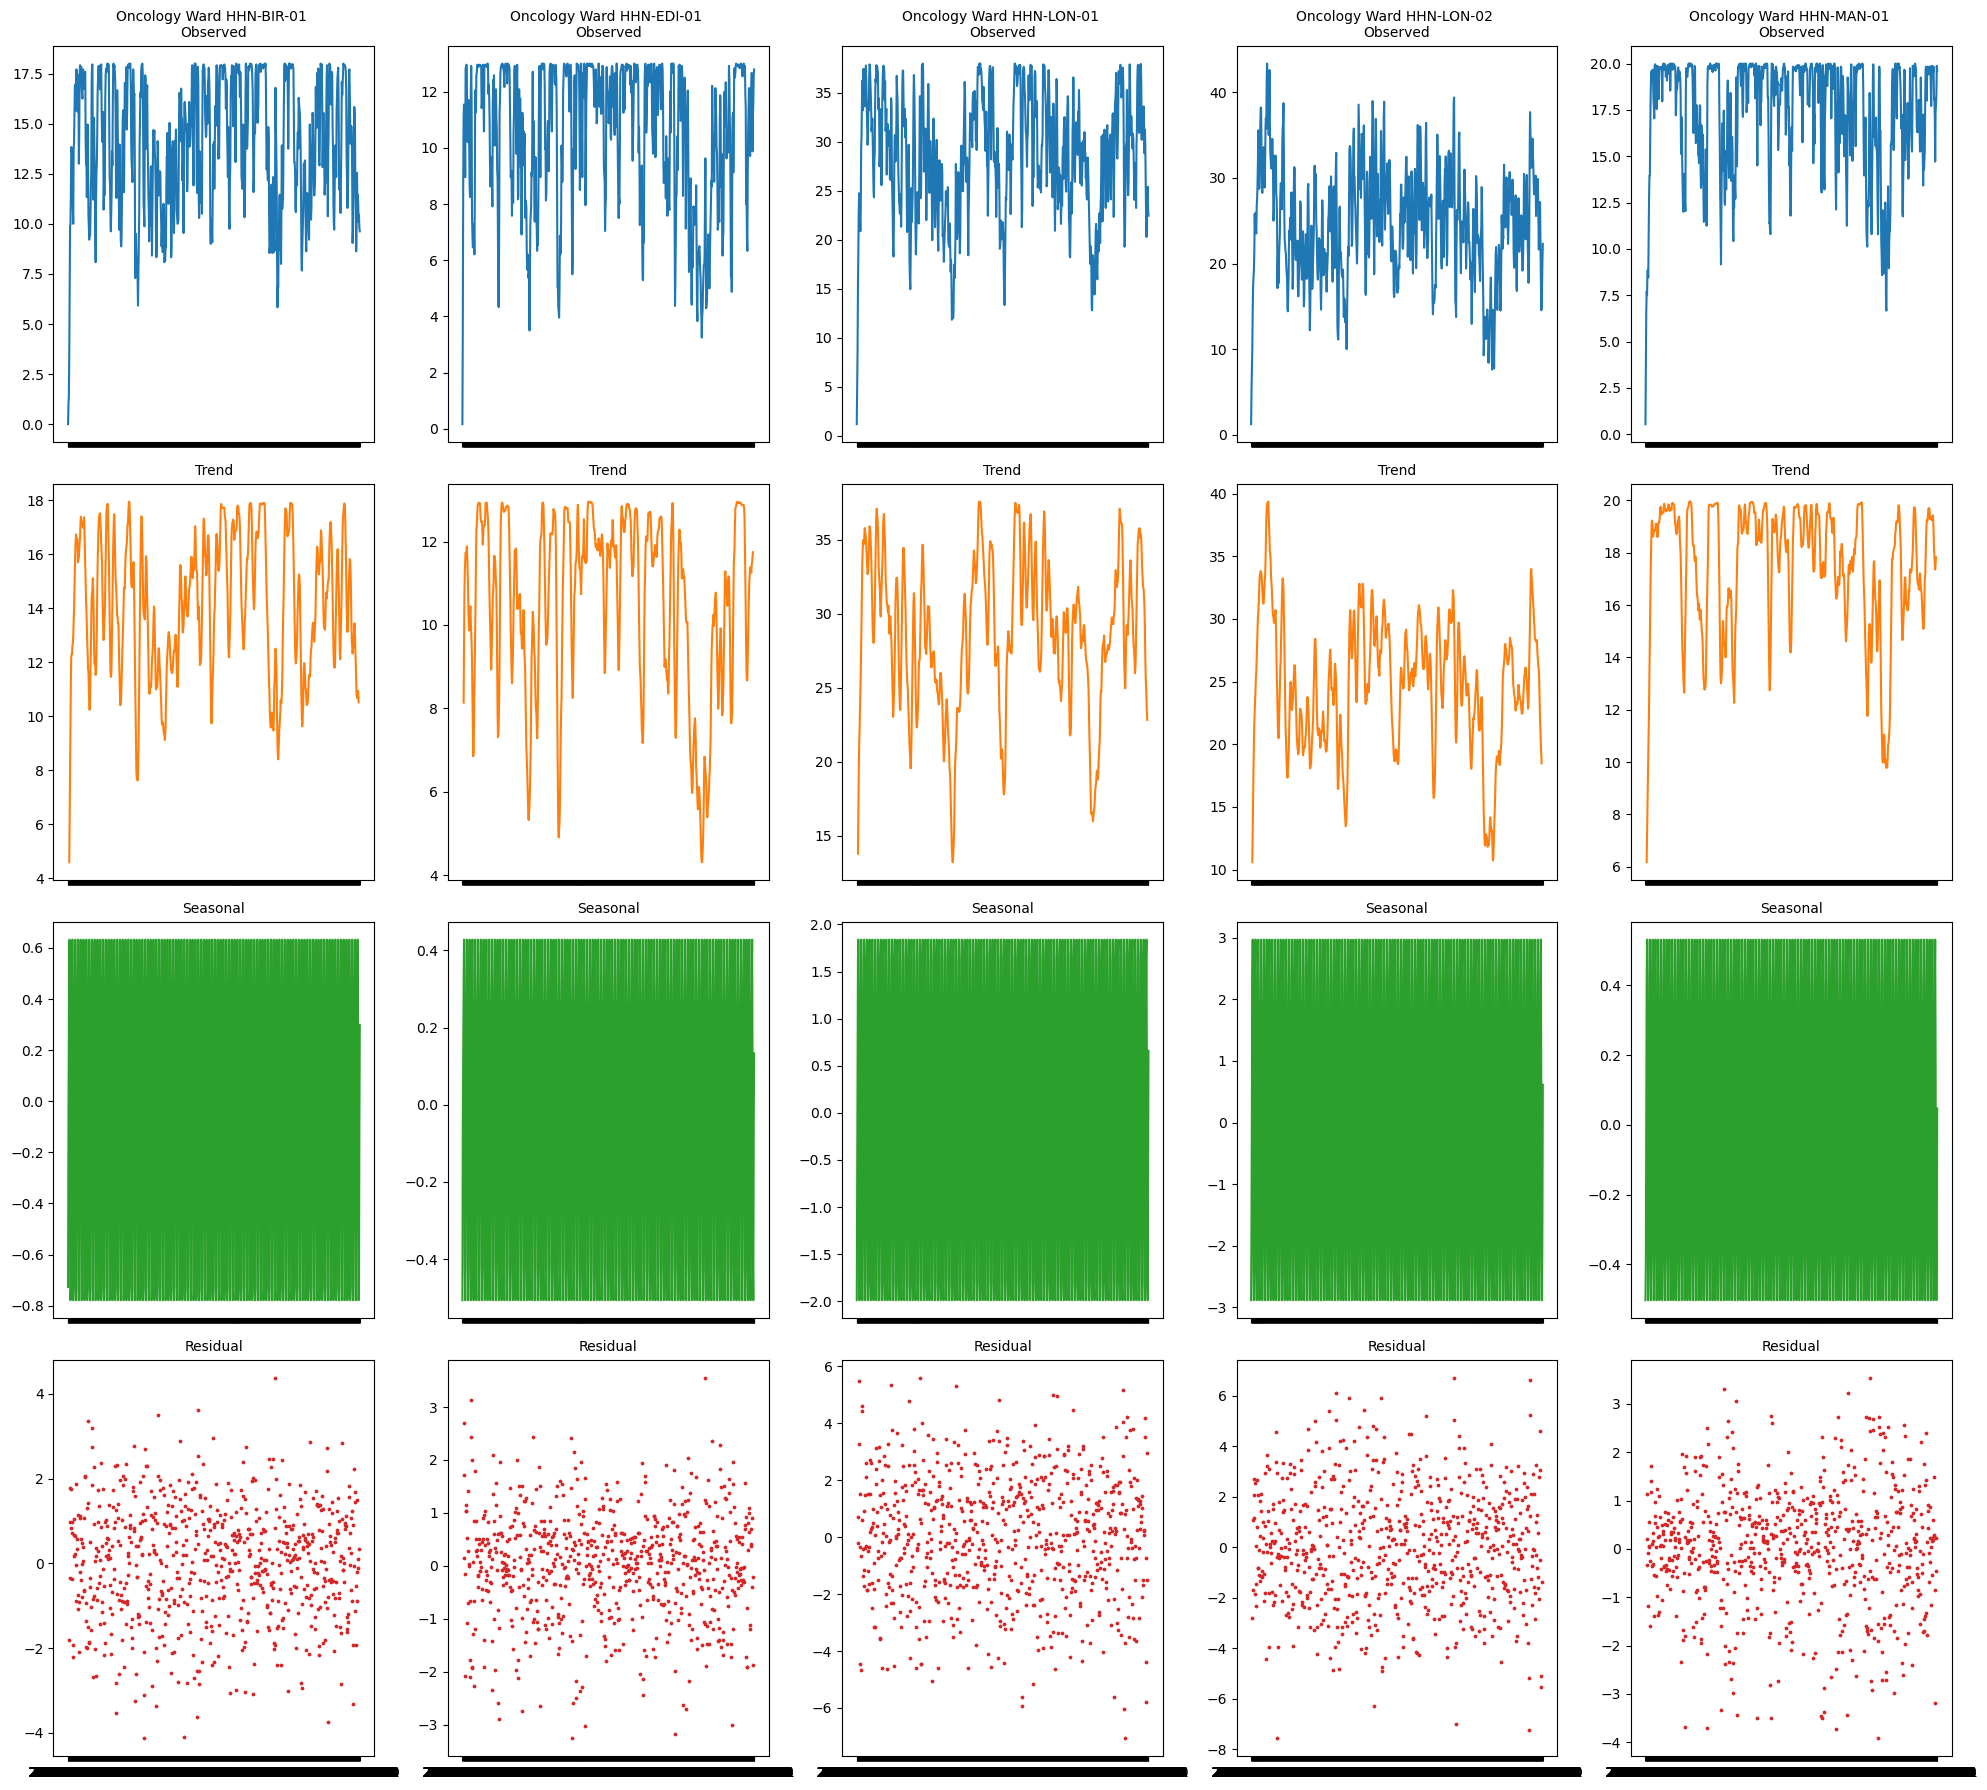

In [17]:
# Create a grid: 4 rows (Observed/Trend/Season/Resid) by X columns (one per hospital)
fig, axes = plt.subplots(4, 5, figsize=(20, 18), sharex=True)

hospitals = sorted(oncology["hospital_id"].unique())
for col_idx, hospital in enumerate(hospitals):
    # Filter and decompose data
    hospital_data = oncology[oncology["hospital_id"] == hospital].sort_values("datetime").set_index("datetime")
    result = seasonal_decompose(hospital_data["occupied_beds"], model="additive", period=7)
    
    # Manually plot each layer into its specific column cell
    axes[0, col_idx].plot(result.observed, color='tab:blue')
    axes[0, col_idx].set_title(f"Oncology Ward {hospital} \nObserved", fontsize=10)
    
    axes[1, col_idx].plot(result.trend, color='tab:orange')
    axes[1, col_idx].set_title("Trend", fontsize=10)
    
    axes[2, col_idx].plot(result.seasonal, color='tab:green')
    axes[2, col_idx].set_title("Seasonal", fontsize=10)
    
    axes[3, col_idx].scatter(result.resid.index, result.resid, color='tab:red', s=3)
    axes[3, col_idx].set_title("Residual", fontsize=10)

plt.tight_layout()
plt.show()


      All hospitals showed stable long-term occupancy patterns with no significant upward or downward trend.
      A clear weekly seasonal pattern was identified, linked to planned treatments and clinical schedules.
      Larger hospitals showed stronger weekly occupancy fluctuations compared with smaller hospitals.
      Residual analysis showed that most predictable patterns were captured by the model.
      Oncology demand is influenced by multi-day patient stays and scheduled treatment cycles.
      The results support the use of SARIMA/SARIMAX models with weekly seasonality for forecasting.